In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention iss all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [ ]:
messages = graph.invoke({"messages":HumanMessage(content="Who is Donald Trump")})
for m in messages["messages"]:
    m.pretty_print()

In [27]:
result = wiki.invoke({"query": "What is machine learning"})
print(result)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [26]:
wiki.invoke(query="What is machine learning")

TypeError: BaseTool.invoke() missing 1 required positional argument: 'input'

In [23]:
wiki.invoke({"messages":HumanMessage(content="What is machine learning")})

ValidationError: 1 validation error for WikipediaQueryInput
query
  Field required [type=missing, input_value={'messages': HumanMessage..., response_metadata={})}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing

In [7]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_PROJECT"]="react-agent"


In [8]:
### Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[arxiv,wiki,add,multiply,divide]

In [9]:
# Tavily search tool
from langchain_tavily import TavilySearch

tavily = TavilySearch()
tavily.invoke("Provide me the recent AI news for march 17th 2026")

{'query': 'Provide me the recent AI news for march 17th 2026',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.linkedin.com/pulse/march-2026-ai-news-roundup-breakthroughs-0staf',
   'title': 'March 2026 AI News Roundup: Breakthroughs and the Fights ...',
   'content': "Alibaba's Qwen AI team lost one of their most visible leaders after the rollout of its new 3.5 models (one of world's most popular open-weight",
   'score': 0.7978881,
   'raw_content': None},
  {'url': 'https://hai.stanford.edu/ai-index/2026-ai-index-report',
   'title': 'The 2026 AI Index Report | Stanford HAI',
   'content': 'Documented AI incidents rose to 362, up from 233 in 2024. Adding to the challenge, recent research found that improving one responsible AI dimension, such as',
   'score': 0.73981786,
   'raw_content': None},
  {'url': 'https://blog.google/products-and-platforms/products/search/search-io-2026',
   'title': "Google Search's I/O 2026 updates: AI agent

In [10]:
tools.append(tavily)

In [11]:
tools

[ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=2, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=500)),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from '/Users/kishore/Documents/Projects/AgenticAIProject/langgraph-project/.venv/lib/python3.11/site-packages/wikipedia/__init__.py'>, top_k_results=1, lang='en', load_all_available_meta=False, doc_content_chars_max=500)),
 <function __main__.add(a: int, b: int) -> int>,
 <function __main__.multiply(a: int, b: int) -> int>,
 <function __main__.divide(a: int, b: int) -> float>,
 TavilySearch(api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))]

In [12]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3-32b")
llm_with_tools = llm.bind_tools(tools)

In [13]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent LPG news in India")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent LPG news in India. Let me break this down. LPG stands for Liquefied Petroleum Gas, which is a common fuel used in households and industries. In India, LPG policies and price changes are often in the news. Since they want recent news, I need to focus on the latest updates.\n\nFirst, I should check what tools I have available. The functions provided include tavily_search, which is good for current events. The parameters for tavily_search allow specifying a time range, which is crucial here because the user is asking for "recent" news. The time_range parameter can be set to "day", "week", "month", or "year". Since "recent" typically means the latest, maybe the last week or month. Also, the start_date and end_date parameters could help narrow it down, but using time_range might be simpler.\n\nI should set the query to "recent LPG news in India". For the time_range, maybe "week" to get the lat

In [15]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [16]:
# Build entire chatbot with Langgraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

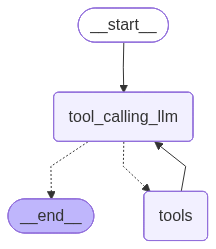

In [18]:
# Build Graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
                              tools_condition,)
builder.add_edge("tools", "tool_calling_llm")
# builder.add_edge("tool_calling_llm", END)

graph = builder.compile()

#View
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
messages = graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for march 2026, add 5 plus 5 and then multiply by 10")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for march 2026, add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (cv2qxwp1z)
 Call ID: cv2qxwp1z
  Args:
    end_date: 2026-03-31
    query: top 10 AI news March 2026
    search_depth: advanced
    start_date: 2026-03-01
    topic: news
  add (zkjrmg173)
 Call ID: zkjrmg173
  Args:
    a: 5
    b: 5
  multiply (46fefd7h2)
 Call ID: 46fefd7h2
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "top 10 AI news March 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.jdsupra.com/legalnews/ai-today-in-5-march-5-2026-the-ai-s-02926/", "title": "AI Today in 5: March 5, 2026, The AI ‘s Biggest Test Edition | Thomas Fox - Compliance Evangelist - JD

In [20]:
messages = graph.invoke({"messages":HumanMessage(content="Who is Donald Trump")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Who is Donald Trump
================================== Ai Message ==================================
Tool Calls:
  wikipedia (t4g75nwzv)
 Call ID: t4g75nwzv
  Args:
    query: Donald Trump
================================= Tool Message =================================
Name: wikipedia

Page: Donald Trump
Summary: Donald John Trump (born June 14, 1946) is an American politician, media personality, and businessman who is the 47th president of the United States. A member of the Republican Party, he served as the 45th president from 2017 to 2021.
Born into a wealthy New York City family, Trump graduated from the University of Pennsylvania in 1968 with a bachelor's degree in economics. He became the president of his family's real estate business in 1971, renamed it the Trump Organi
================================== Ai Message ==================================

Donald John Trump is an American politician, med

### Agent memory - Lets introduce Agent with memory

In [28]:
messages = graph.invoke({"messages":HumanMessage(content="What is 10 plus 6")})

In [30]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 10 plus 6
================================== Ai Message ==================================
Tool Calls:
  add (xvh993ff3)
 Call ID: xvh993ff3
  Args:
    a: 10
    b: 6
================================= Tool Message =================================
Name: add

16
================================== Ai Message ==================================

The result of adding 10 and 6 is $\boxed{16}$.


In [31]:
messages = graph.invoke({"messages":HumanMessage(content="Divide the result by 8")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide the result by 8
================================== Ai Message ==================================

To perform the division, I need to know the specific number you want to divide by 8. Could you please provide the value to be divided? For example, "Divide 40 by 8" would use the `divide` function with a=40 and b=8.


This is not working since the memory layer is absent and the graph doesn't remember what it just did. 
That's where the InMemorySaver() comes into picture

In [32]:
# Build Graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
                              tools_condition,)
builder.add_edge("tools", "tool_calling_llm")

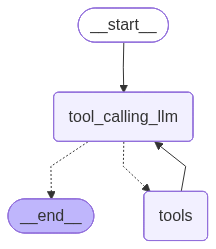

In [33]:
from langgraph.checkpoint.memory import InMemorySaver

memory=InMemorySaver()
graph_memory = builder.compile(checkpointer=memory)

#View
display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
# Specify the thread

config = {"configurable":{"thread_id":"1"}}

# Specify an input

messages = graph_memory.invoke({"messages":HumanMessage(content="Add 2 and 7")}, config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 2 and 7
================================== Ai Message ==================================
Tool Calls:
  add (n0nz5ydej)
 Call ID: n0nz5ydej
  Args:
    a: 2
    b: 7
================================= Tool Message =================================
Name: add

9
================================== Ai Message ==================================

The sum of 2 and 7 is **9**.


In [36]:
messages = graph_memory.invoke({"messages":HumanMessage(content="Multiply the result with 3")}, config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 2 and 7
================================== Ai Message ==================================
Tool Calls:
  add (n0nz5ydej)
 Call ID: n0nz5ydej
  Args:
    a: 2
    b: 7
================================= Tool Message =================================
Name: add

9
================================== Ai Message ==================================

The sum of 2 and 7 is **9**.
================================ Human Message =================================

Multiply the result with 3
================================== Ai Message ==================================
Tool Calls:
  multiply (hvcfqz542)
 Call ID: hvcfqz542
  Args:
    a: 9
    b: 3
================================= Tool Message =================================
Name: multiply

27
================================== Ai Message ==================================

The result of multiplying 9 by 3 is **27**.


In [37]:
messages = graph_memory.invoke({"messages":HumanMessage(content="Subtract 27 from it")}, config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 2 and 7
================================== Ai Message ==================================
Tool Calls:
  add (n0nz5ydej)
 Call ID: n0nz5ydej
  Args:
    a: 2
    b: 7
================================= Tool Message =================================
Name: add

9
================================== Ai Message ==================================

The sum of 2 and 7 is **9**.
================================ Human Message =================================

Multiply the result with 3
================================== Ai Message ==================================
Tool Calls:
  multiply (hvcfqz542)
 Call ID: hvcfqz542
  Args:
    a: 9
    b: 3
================================= Tool Message =================================
Name: multiply

27
================================== Ai Message ==================================

The result of multiplying 9 by 3 is **27**.
================================ Human Message 